<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path
from datetime import datetime

from scipy.integrate import odeint
from posterior_plot import plot_posterior_kde_grid

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p\\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

In [3]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    C = state[4*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma[i] * E[i]
        dI[i] =  sigma[i] * E[i] - gamma[i] * I[i]
        dR[i] =  gamma[i] * I[i]
        dC[i] = sigma[i] * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dC.flatten()])


# Define Parameters

In [4]:
np.array([1/9, 1/7, 1/6])*7

array([0.77777778, 1.        , 1.16666667])

In [5]:
n_regions = 3 
T = 96  #371/7 #96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N = np.array([1100000, 440000, 680000])
## Get the Parameters
beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/7)*7     # 1/infectious period per week (Ebola: ~7 days)

sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

# Initial conditions
E0 = np.array([10, 1, 1])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
C0 = np.array([10,10,10])
S0 = np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), C0.flatten()])


# Solve the ODEs

In [6]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma, N))

## Get the New Infections and Deaths

In [7]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
C_total = sol[:, 4*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

## Show New infections

In [8]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.30821271e+01, 8.49152847e+00, 7.01733177e+00],
       [2.35605344e+01, 2.04899598e+01, 1.45945881e+01],
       [3.98138816e+01, 3.83345977e+01, 2.29851596e+01],
       [6.69911848e+01, 7.09900452e+01, 3.57252426e+01],
       [1.12685274e+02, 1.31398044e+02, 5.54861707e+01],
       [1.89540455e+02, 2.43192538e+02, 8.61732417e+01],
       [3.18806073e+02, 4.50062594e+02, 1.33829638e+02],
       [5.36210507e+02, 8.32769534e+02, 2.07836353e+02],
       [9.01814719e+02, 1.54044369e+03, 3.22755933e+02],
       [1.51654173e+03, 2.84789999e+03, 5.01188802e+02],
       [2.54985696e+03, 5.25964289e+03, 7.78195543e+02],
       [4.28598052e+03, 9.69532130e+03, 1.20813206e+03],
       [7.20063844e+03, 1.78093700e+04, 1.87518574e+03],
       [1.20874067e+04, 3.25050624e+04, 2.90954795e+03],
       [2.02625199e+04, 5.86404030e+04, 4.51207315e+03],
       [3.38879909e+04, 1.03609492e+05, 6.99148200e+03],
       [5.64566231e+04, 1.76547

## Add Noise

In [9]:
from add_noise import Add_noise

observed_cases = Add_noise(Infections, reporting_rate= reporting_rate, phi=phi, seed=0)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [10]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
}

raw = pd.DataFrame(data)
raw.to_csv('Data/synthetic_dataset_no_coupling.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149998e+07,10.000000,10.000000,0.000000,10.000000,0.000000,0,4.499989e+06,...,10.000000,0.000000,0,6.799989e+06,1.000000,10.000000,0.000000,10.000000,0.000000,0
1,2013-12-29,1,1.149996e+07,21.351046,14.032778,9.049349,23.082127,13.082127,8,4.499964e+06,...,18.491528,8.491528,12,6.799970e+06,13.467139,7.738984,9.278348,17.017332,7.017332,9
2,2013-12-30,2,1.149992e+07,36.448061,23.275623,23.367039,46.642662,23.560534,25,4.499928e+06,...,38.981488,20.489960,30,6.799946e+06,21.942338,11.347891,20.264029,31.611920,14.594588,9
3,2013-12-31,3,1.149985e+07,61.371156,39.112605,47.343938,86.456543,39.813882,27,4.499861e+06,...,77.316086,38.334598,25,6.799911e+06,34.166770,17.566403,37.030676,54.597079,22.985160,31
4,2014-01-01,4,1.149974e+07,103.237457,65.785494,87.662234,153.447728,66.991185,67,4.499737e+06,...,148.306131,70.990045,73,6.799857e+06,53.071222,27.277061,63.045261,90.322322,35.725243,26


# Plot the results

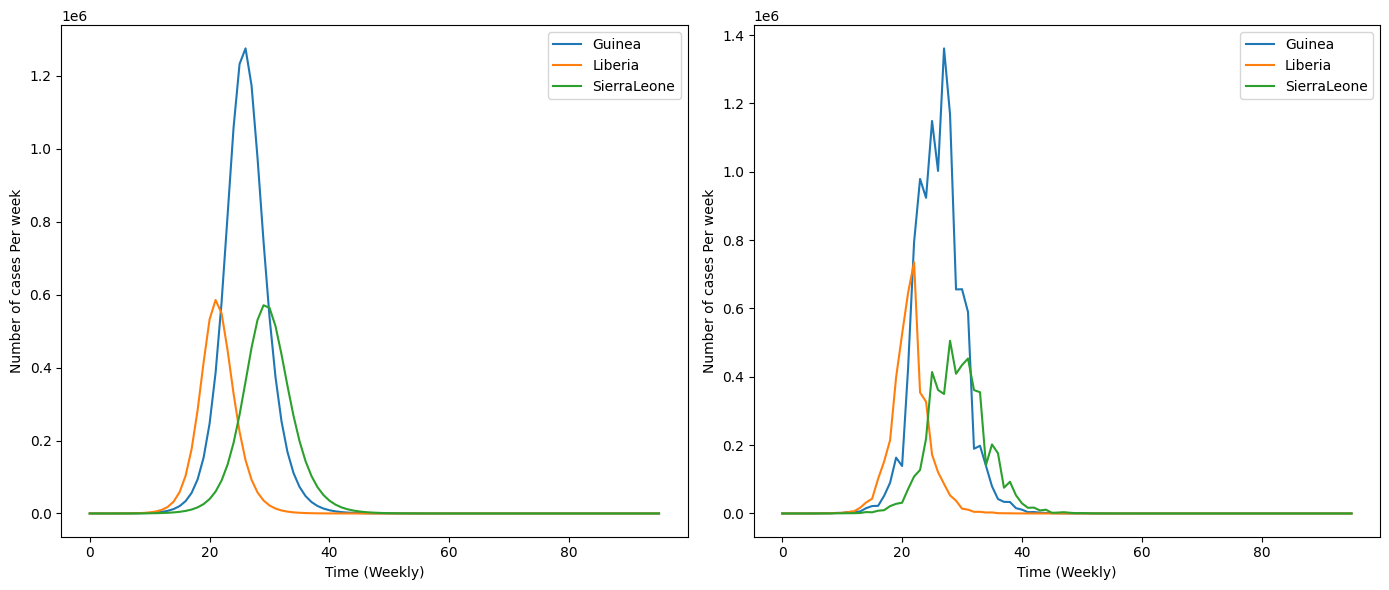

In [11]:
fig, ax = plt.subplots(1,2, figsize = (14, 6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    # ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    # ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    # ax[2].plot(raw[f'C_{countries[i]}'])
    # ax[2].legend(countries)
    # ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    # ax[2].set_xlabel('Time (Weekly)')
    # ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.savefig('images/generated_no_coupling.pdf')
plt.show()

In [12]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Removed', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

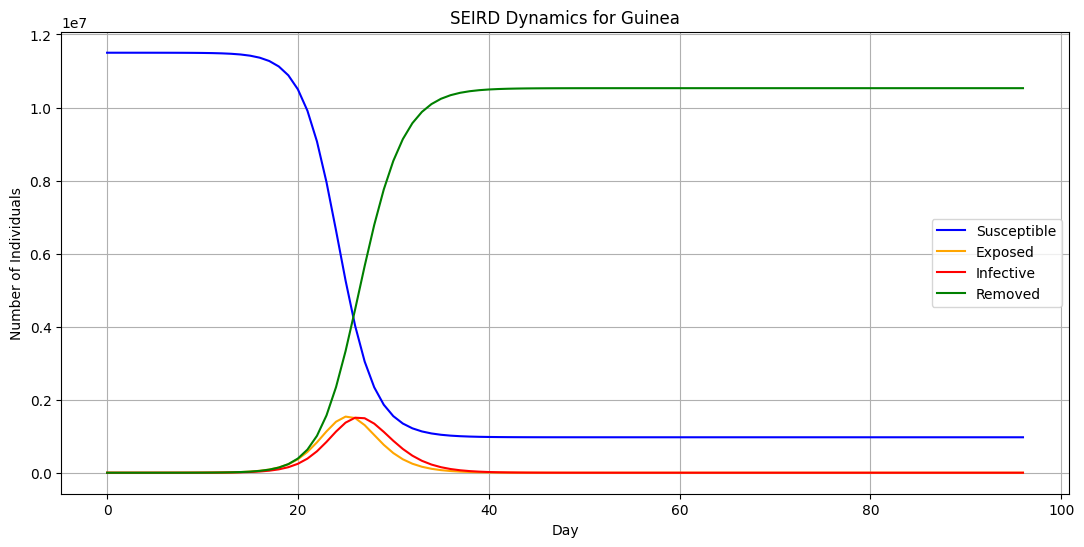

In [13]:
plot_SEIR(raw, 'Guinea')

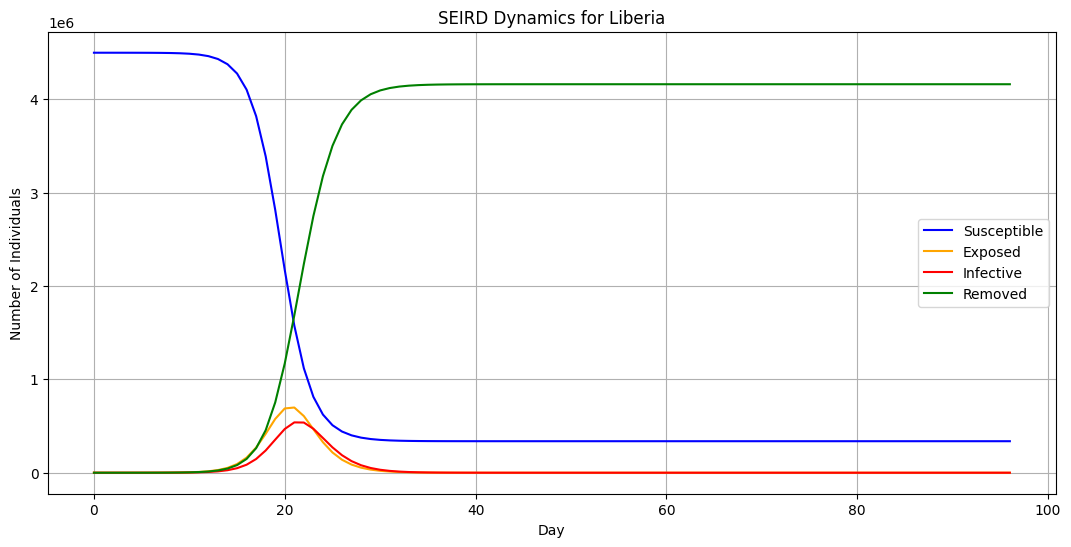

In [14]:
plot_SEIR(raw, 'Liberia')

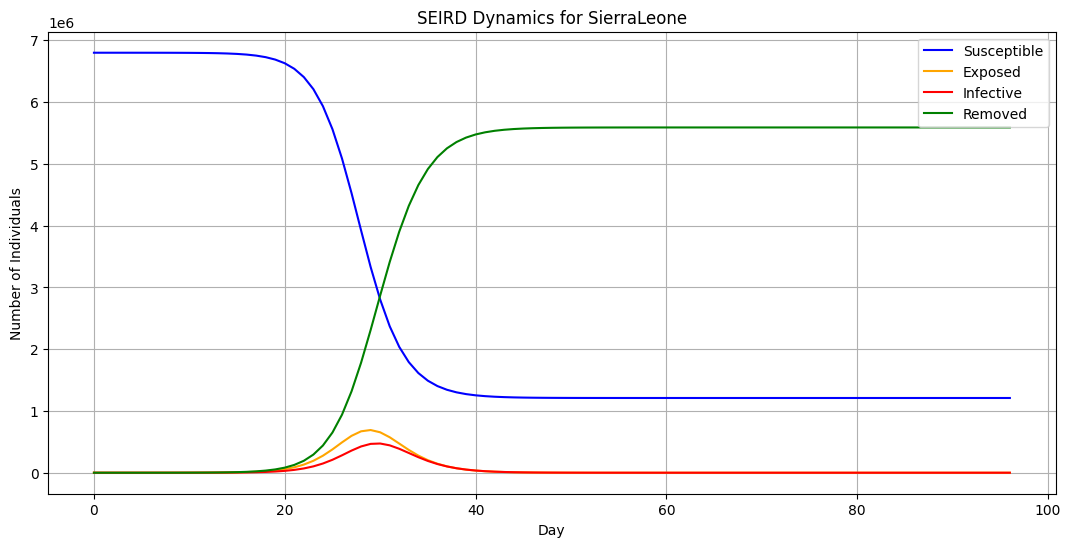

In [15]:
plot_SEIR(raw, 'SierraLeone')

# Create a function to plot Posterior for Parameters

# Fit the Model to daily cases


In [40]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases1 = raw['Guinea_Noise']
weekly_cases2 = raw['Liberia_Noise']
weekly_cases3 = raw['SierraLeone_Noise']

cases1 = weekly_cases1.values  # Shape: (T, 3)
cases2 = weekly_cases2.values  # Shape: (T, 3)
cases3 = weekly_cases3.values  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6])

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/6)*7 
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 

# Define initial conditions
i0 = [10, 10, 10]
e0 = [10, 1, 1]
s0 = N - i0 - e0
r0 = [0, 0, 0]
c0 = [10, 10, 10]
y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [41]:

# Make the data struture
seir_data1 = {
    "n_days": len(cases1),
    "y0": y1,
    "t0": 0,
    "t": np.arange(1, len(cases1)+1),
    "N": int(N[0]),
    "cases": cases1,
    'beta_value': beta[0],
    'sigma_value': sigma[0],
    'gamma_value': gamma[0],
    "reporting_rate": reporting_rate
}

seir_data2 = {
    "n_days": len(cases2),
    "y0": y2,
    "t0": 0,
    "t": np.arange(1, len(cases2)+1),
    "N": int(N[1]),
    "cases": cases2,
    'beta_value': beta[1],
    'sigma_value': sigma[1],
    'gamma_value': gamma[1],
    "reporting_rate": reporting_rate
}
seir_data3 = {
    "n_days": len(cases3),
    "y0": y3,
    "t0": 0,
    "t": np.arange(1, len(cases3)+1),
    "N": int(N[2]),
    "cases": cases3,
    'beta_value': beta[2],
    'sigma_value': sigma[2],
    'gamma_value': gamma[2],
    "reporting_rate": reporting_rate
}

In [18]:
seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
# %run fit_single.py
fit1 = seir_incidence_model1.sample(data = seir_data1,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the fit output with a memorable name
output_dir = f'outputs/Guinea_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit1.save_csvfiles(dir=output_dir)
print(f"\nFit for Guinea saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits for Guinea completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 07:42 Iteration: 1900 / 2000 [ 95%]  (Sampling)
































































chain 1 |██████████| 26:40 Sampling completed                       
chain 2 |██████████| 26:40 Sampling completed                       
chain 3 |██████████| 26:40 Sampling completed                       
chain 4 |██████████| 26:40 Sampling completed                       



Fit for Guinea saved to: outputs/Guinea_20250610_150303
Fits for Guinea completed. Check 'output/' directory.


In [42]:
# %run fit_single.py

seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
fit2 = seir_incidence_model2.sample(data = seir_data2,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the fit output with a memorable name
output_dir = f'outputs/Liberia_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit2.save_csvfiles(dir=output_dir)
print(f"\nFit Liberia saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits Liberia completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 01:44 Iteration: 1900 / 2000 [ 95%]  (Sampling)






























































chain 1 |██████████| 17:05 Sampling completed                       
chain 2 |██████████| 17:05 Sampling completed                       
chain 3 |██████████| 17:05 Sampling completed                       
chain 4 |██████████| 17:05 Sampling completed                       



Fit Liberia saved to: outputs/Liberia_20250610_171309
Fits Liberia completed. Check 'output/' directory.


In [23]:
# %run fit_single.py
seir_incidence_model3 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
fit3 = seir_incidence_model3.sample(data = seir_data3,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')  # e.g., 20250607_103939

# Save the fit output with a memorable name
output_dir = f'outputs/Sierraleone_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit3.save_csvfiles(dir=output_dir)
print(f"\nFit Sierra Leone saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits Sierra Leone completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 11:06 Iteration: 1900 / 2000 [ 95%]  (Sampling)
































































chain 1 |██████████| 53:33 Sampling completed                       
chain 2 |██████████| 53:33 Sampling completed                       
chain 3 |██████████| 53:33 Sampling completed                       
chain 4 |██████████| 53:33 Sampling completed                       



Fit Sierra Leone saved to: outputs/Sierraleone_20250610_164959
Fits Sierra Leone completed. Check 'output/' directory.


In [43]:
from cmdstanpy import from_csv

# Load Guinea fit
fit1 = from_csv('outputs/Guinea_20250610_150303/simple_seir-*_*.csv')
print("Guinea fit loaded")

# Load Liberia fit
fit2 = from_csv('outputs/Liberia_20250610_171309/simple_seir-*_*.csv')
# fit2 = from_csv('outputs/liberia_20250608_055540/simple_seir-*_*.csv')
print("Liberia fit loaded")

# # Load Sierra Leone fit
# fit3 = from_csv('outputs/sierraleone_20250608_060434/simple_seir-*_*.csv')
fit3 = from_csv('outputs/Sierraleone_20250610_164959/simple_seir-*_*.csv')
print("Sierra Leone fit loaded")

Guinea fit loaded
Liberia fit loaded
Sierra Leone fit loaded


In [44]:
print(fit2.diagnose())

Checking sampler transitions treedepth.
21 of 1000 (2.10%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
3978 of 1000 (397.80%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.02, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  y[84

In [21]:
fit1_summary = fit1.summary()
fit1_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.872585,0.002288,0.101347,0.097073,0.727969,0.862782,1.052150,1939.90,1822.01,1.00219
beta,2.168350,0.004490,0.164691,0.154991,1.925560,2.149560,2.457410,1548.16,1412.01,1.00292
gamma,0.872409,0.003282,0.116180,0.107352,0.707489,0.860173,1.082860,1329.86,1498.10,1.00290
recovery_time,1.165910,0.004148,0.150488,0.145688,0.923484,1.162560,1.413450,1329.84,1498.10,1.00297
incubation_period,1.161020,0.002967,0.130926,0.131040,0.950428,1.159040,1.373690,1939.95,1822.01,1.00219
R0,2.508810,0.005455,0.213577,0.210025,2.186060,2.491620,2.869470,1591.35,1775.54,1.00343
phi,7.372970,0.035067,1.635120,1.607170,4.986200,7.229870,10.265500,2234.00,2186.21,1.00188
phi_inv,0.142379,0.000683,0.031875,0.030616,0.097413,0.138315,0.200553,2234.00,2186.21,1.00174


In [45]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,1.783780,NaN,1.109680,0.979016,0.716179,1.461750,3.51006,NaN,NaN,NaN
beta,2.214830,NaN,0.640763,0.383734,1.682200,1.943430,3.27109,NaN,NaN,NaN
gamma,0.867570,NaN,0.176570,0.151757,0.710148,0.812507,1.14625,NaN,NaN,NaN
recovery_time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incubation_period,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phi,3.210790,NaN,2.257690,3.263310,0.873793,3.075380,5.57576,NaN,NaN,NaN
phi_inv,0.618097,NaN,0.439603,0.592001,0.179348,0.578647,1.14444,NaN,NaN,NaN


In [28]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.953104,0.003238,0.151445,0.141177,0.738453,0.936727,1.228730,2265.74,1843.36,1.00293
beta,2.017740,0.006596,0.239412,0.226045,1.685070,1.983640,2.480820,1409.81,1188.10,1.00163
gamma,0.952479,0.004829,0.172266,0.156508,0.715378,0.926872,1.287740,1408.19,1417.83,1.00089
recovery_time,1.082800,0.005000,0.187370,0.184626,0.776554,1.078900,1.397860,1408.18,1417.83,1.00089
incubation_period,1.074680,0.003466,0.164415,0.160801,0.813844,1.067540,1.354180,2265.73,1843.36,1.00223
R0,2.146410,0.004821,0.200295,0.192493,1.850130,2.123710,2.506180,1798.00,1894.01,1.00075
phi,8.547830,0.035310,1.649310,1.649160,6.091390,8.400600,11.401200,2203.38,2157.44,1.00114
phi_inv,0.121518,0.000534,0.024449,0.023225,0.087710,0.119039,0.164166,2203.38,2157.44,1.00114


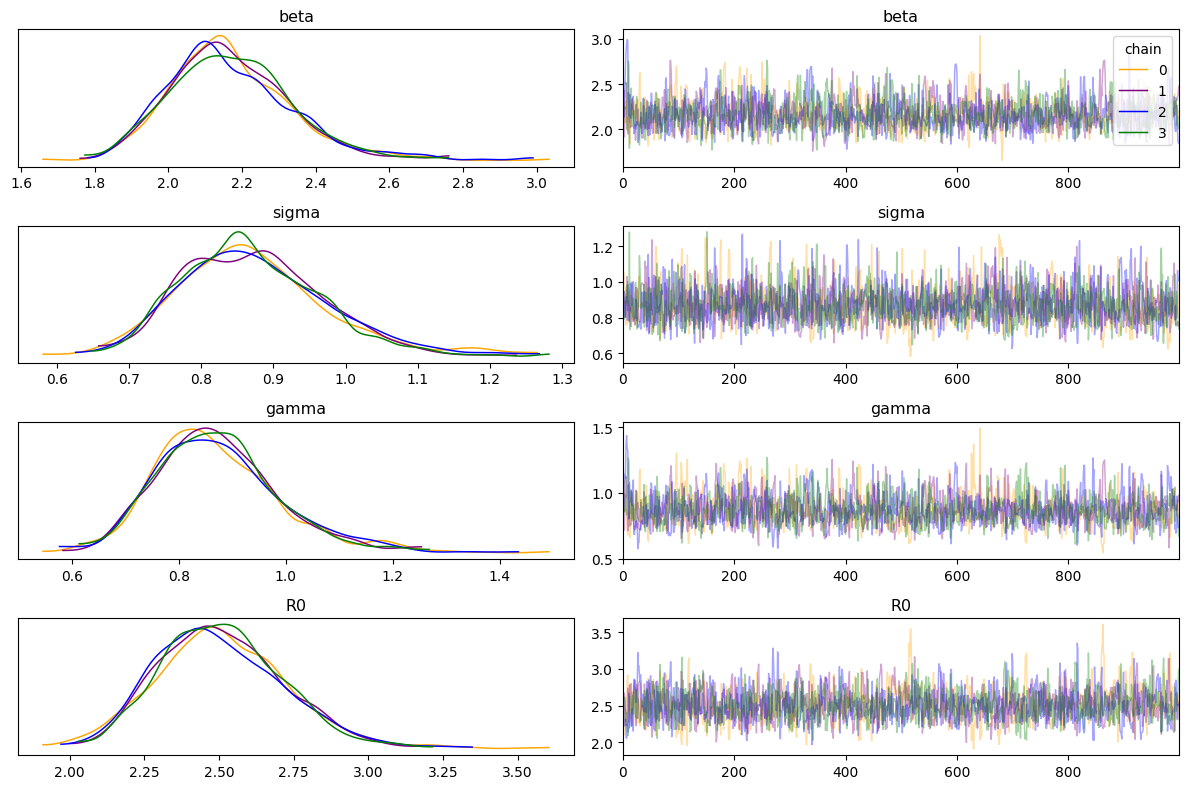

In [29]:
## trace plots
axes = az.plot_trace(fit1, 
              var_names=["beta", "sigma", "gamma", "R0"],
            #   figsize=(12, 8),
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to 

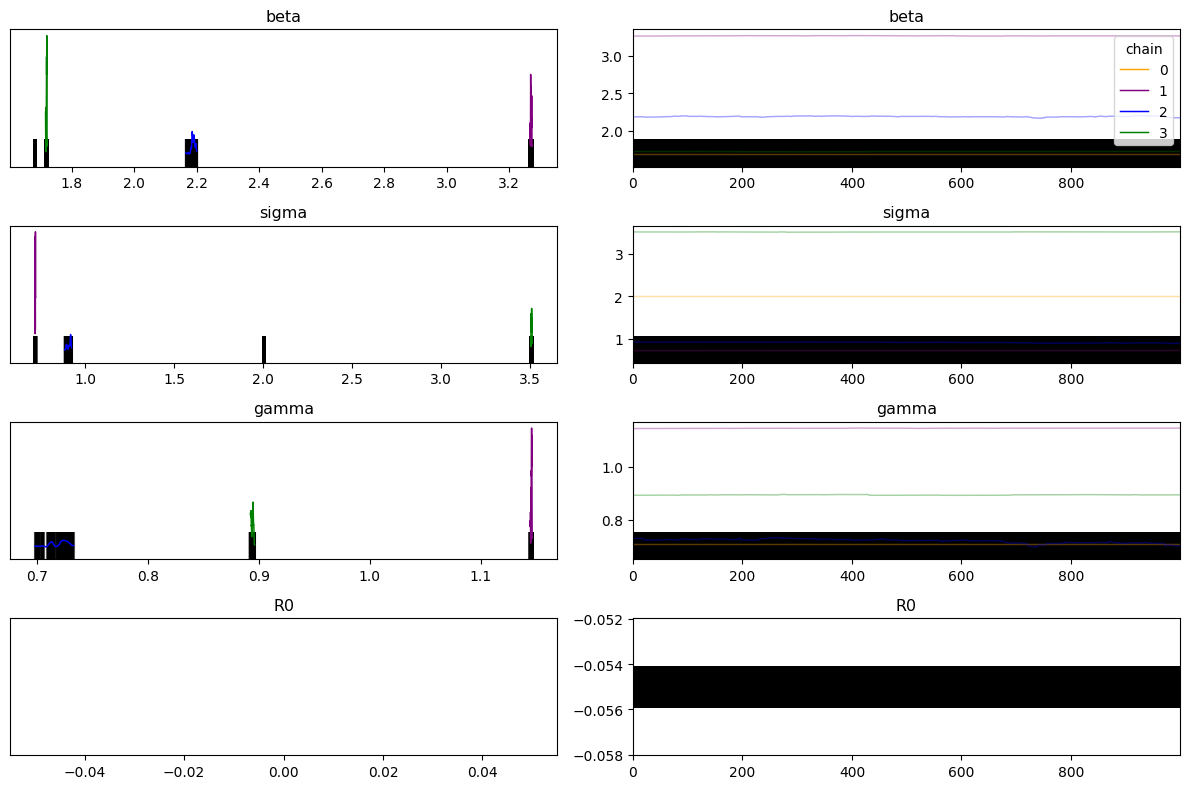

In [30]:
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

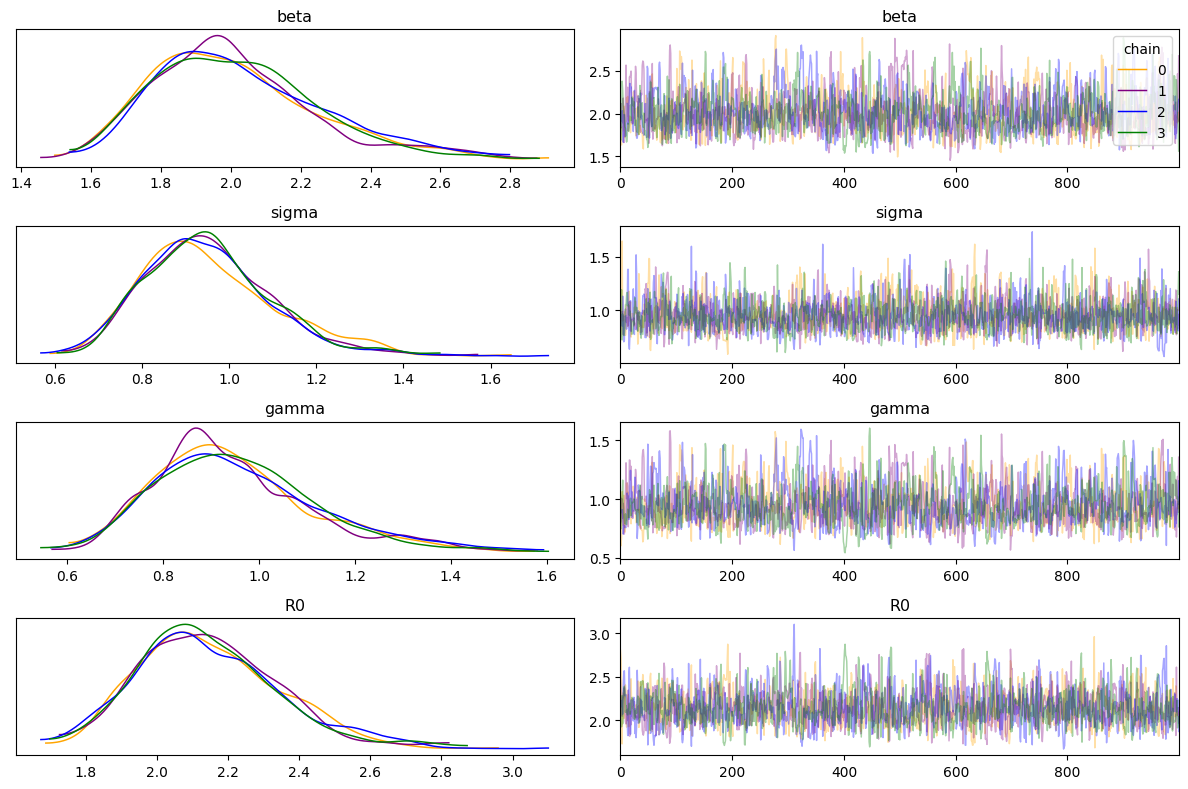

In [31]:
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

In [ ]:
# Extract posterior samples
# post_guinea = fit1.draws_pd()
# post_liberia = fit2.draws_pd()
# post_sierra = fit3.draws_pd()

# ## save the posterior samples
# post_guinea.to_csv('./Data/posterior_samples_guinea.csv', index=False)
# post_liberia.to_csv('./Data/posterior_samples_liberia.csv', index=False)
# post_sierra.to_csv('./Data/posterior_samples_sierra.csv', index=False)

# Posterior Predictive Checks

In [134]:
# idata_gp = az.from_cmdstanpy(fit1)
# custom_summary_fns = {
# 	'median': lambda x: np.percentile(x, 50),
# 	'q2.5': lambda x: np.percentile(x, 2.5),
# 	'q97.5': lambda x: np.percentile(x, 97.5),
# }

# mu_sum_gp = az.summary(idata_gp, var_names=['pred_incidence'], stat_funcs=custom_summary_fns, extend=False)

# # mask = mu_sum_gp.index.str.endswith(', 2]') ## get only the infecetious state
# # mu_sum_gp = mu_sum_gp[mask]


# def plot_posterior_summary(year, y, posterior_summary):
# 	fig, ax = plt.subplots(1, 1, figsize=(14, 8))
# 	ax.scatter(year, y, label='Data',)
# 	ax.plot(year, posterior_summary['median'], label='Posterior Median of Incidence', color='red')
# 	ax.fill_between(year, posterior_summary['q2.5'], posterior_summary['q97.5'], color='gray', alpha=0.2, label='95% CI')
# 	ax.set_title('Posterior Median of Incidence vs Data')
# 	ax.set_xlabel('time (weeks)')
# 	ax.set_ylabel('Cases')
# 	ax.legend()
# 	plt.show()


# # Example usage:
# plot_posterior_summary(raw['time'], raw['Guinea_Noise'], mu_sum_gp)

In [32]:
idata_gp1 = az.from_cmdstanpy(fit1)
pred_draws = idata_gp1.posterior['pred_incidence'].stack(sample=("chain", "draw")).values  # shape: (n_samples, T)
# Compute statistics
percentiles = np.percentile(pred_draws, [2.5, 50, 97.5], axis=1)
# percentiles shape: (3, T)
df1 = pd.DataFrame({
    't': np.arange(1, T+1),
    '2.5%': percentiles[0],
    '50%': percentiles[1],
    '97.5%': percentiles[2],
    'incidence': cases1
}).set_index('t')

idata_gp2 = az.from_cmdstanpy(fit2)
pred_draws2 = idata_gp2.posterior['pred_incidence'].stack(sample=("chain", "draw")).values  # shape: (n_samples, T)

percentiles2 = np.percentile(pred_draws2, [2.5, 50, 97.5], axis=1)
# percentiles shape: (3, T)
df2 = pd.DataFrame({
    't': np.arange(1, T+1),
    '2.5%': percentiles2[0],
    '50%': percentiles2[1],
    '97.5%': percentiles2[2],
    'incidence': cases2
}).set_index('t')

idata_gp3 = az.from_cmdstanpy(fit3)
pred_draws3 = idata_gp3.posterior['pred_incidence'].stack(sample=("chain", "draw")).values  # shape: (n_samples, T)

percentiles3 = np.percentile(pred_draws3, [2.5, 50, 97.5], axis=1)
# percentiles shape: (3, T)
df3 = pd.DataFrame({
    't': np.arange(1, T+1),
    '2.5%': percentiles3[0],
    '50%': percentiles3[1],
    '97.5%': percentiles3[2],
    'incidence': cases3
}).set_index('t')


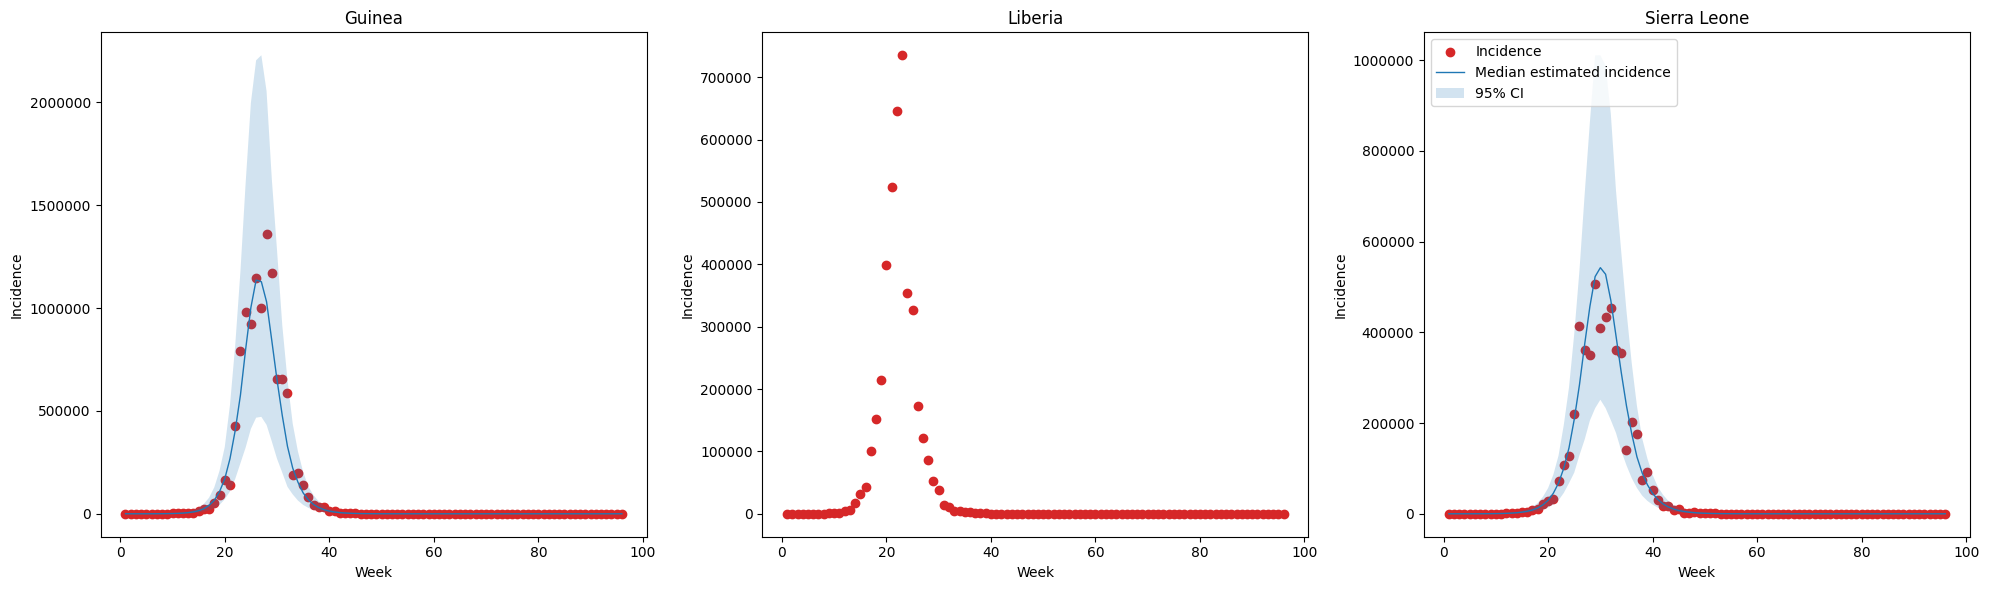

In [33]:
import matplotlib.pyplot as plt

titles = ['Guinea', 'Liberia', 'Sierra Leone']
post_preds = [df1, df2, df3]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for i, (ax, title, df) in enumerate(zip(axes, titles, post_preds)):
    ax.set_title(title)
    ax.set_ylabel('Incidence')
    ax.set_xlabel('Week')
    ax.scatter(df.index, df.incidence, color='tab:red', label="Incidence")
    ax.plot(df['50%'], color='tab:blue', linewidth=1, label="Median estimated incidence")
    ax.fill_between(df.index, df['2.5%'], df['97.5%'], alpha=0.2, label="95% CI")
    ax.ticklabel_format(style='plain', axis='y')
    if i == 2:
        ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig('images/poseterior_check_simple.pdf')


In [136]:
# post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
# post_pred2["t"] = range(1, T+1)
# post_pred2["incidence"] = list(cases2)
# post_pred2 = post_pred2.set_index("t")

# plt.figure(figsize=(12, 7))
# plt.grid(True, which='both', color = 'k', alpha = 0.1)
# plt.title(f'Posterior check for Liberia')
# plt.ylabel('Incidence')
# plt.xlabel('Week')
# plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
# plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
# plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# # plt.facecolor('white')
# plt.legend(loc = "upper right")

In [35]:
# post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
# post_pred3["t"] = range(1, T+1)
# post_pred3["incidence"] = list(cases3)
# post_pred3 = post_pred3.set_index("t")

# plt.figure(figsize=(12, 7))
# plt.grid(True, which='both', color = 'k', alpha = 0.1)
# plt.title(f'Posterior check for Sierra Leone')
# plt.ylabel('Incidence')
# plt.xlabel('Week')
# plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
# plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
# plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# # plt.facecolor('white')
# plt.legend(loc = "upper right")

In [36]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/8.5)*7             #incubation rate per week
# gamma = (1/6)*7 
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma[0], 'gamma': gamma[0], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec[0],
    'incubation_period': incu[0]}

t2 = {'beta':beta[1],'sigma': sigma[1], 'gamma': gamma[1], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec[1],
    'incubation_period': incu[1]}

t3 = {'beta':beta[2],'sigma': sigma[2], 'gamma': gamma[2], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[2], 'recovery_time':rec[2],
    'incubation_period': incu[2]}

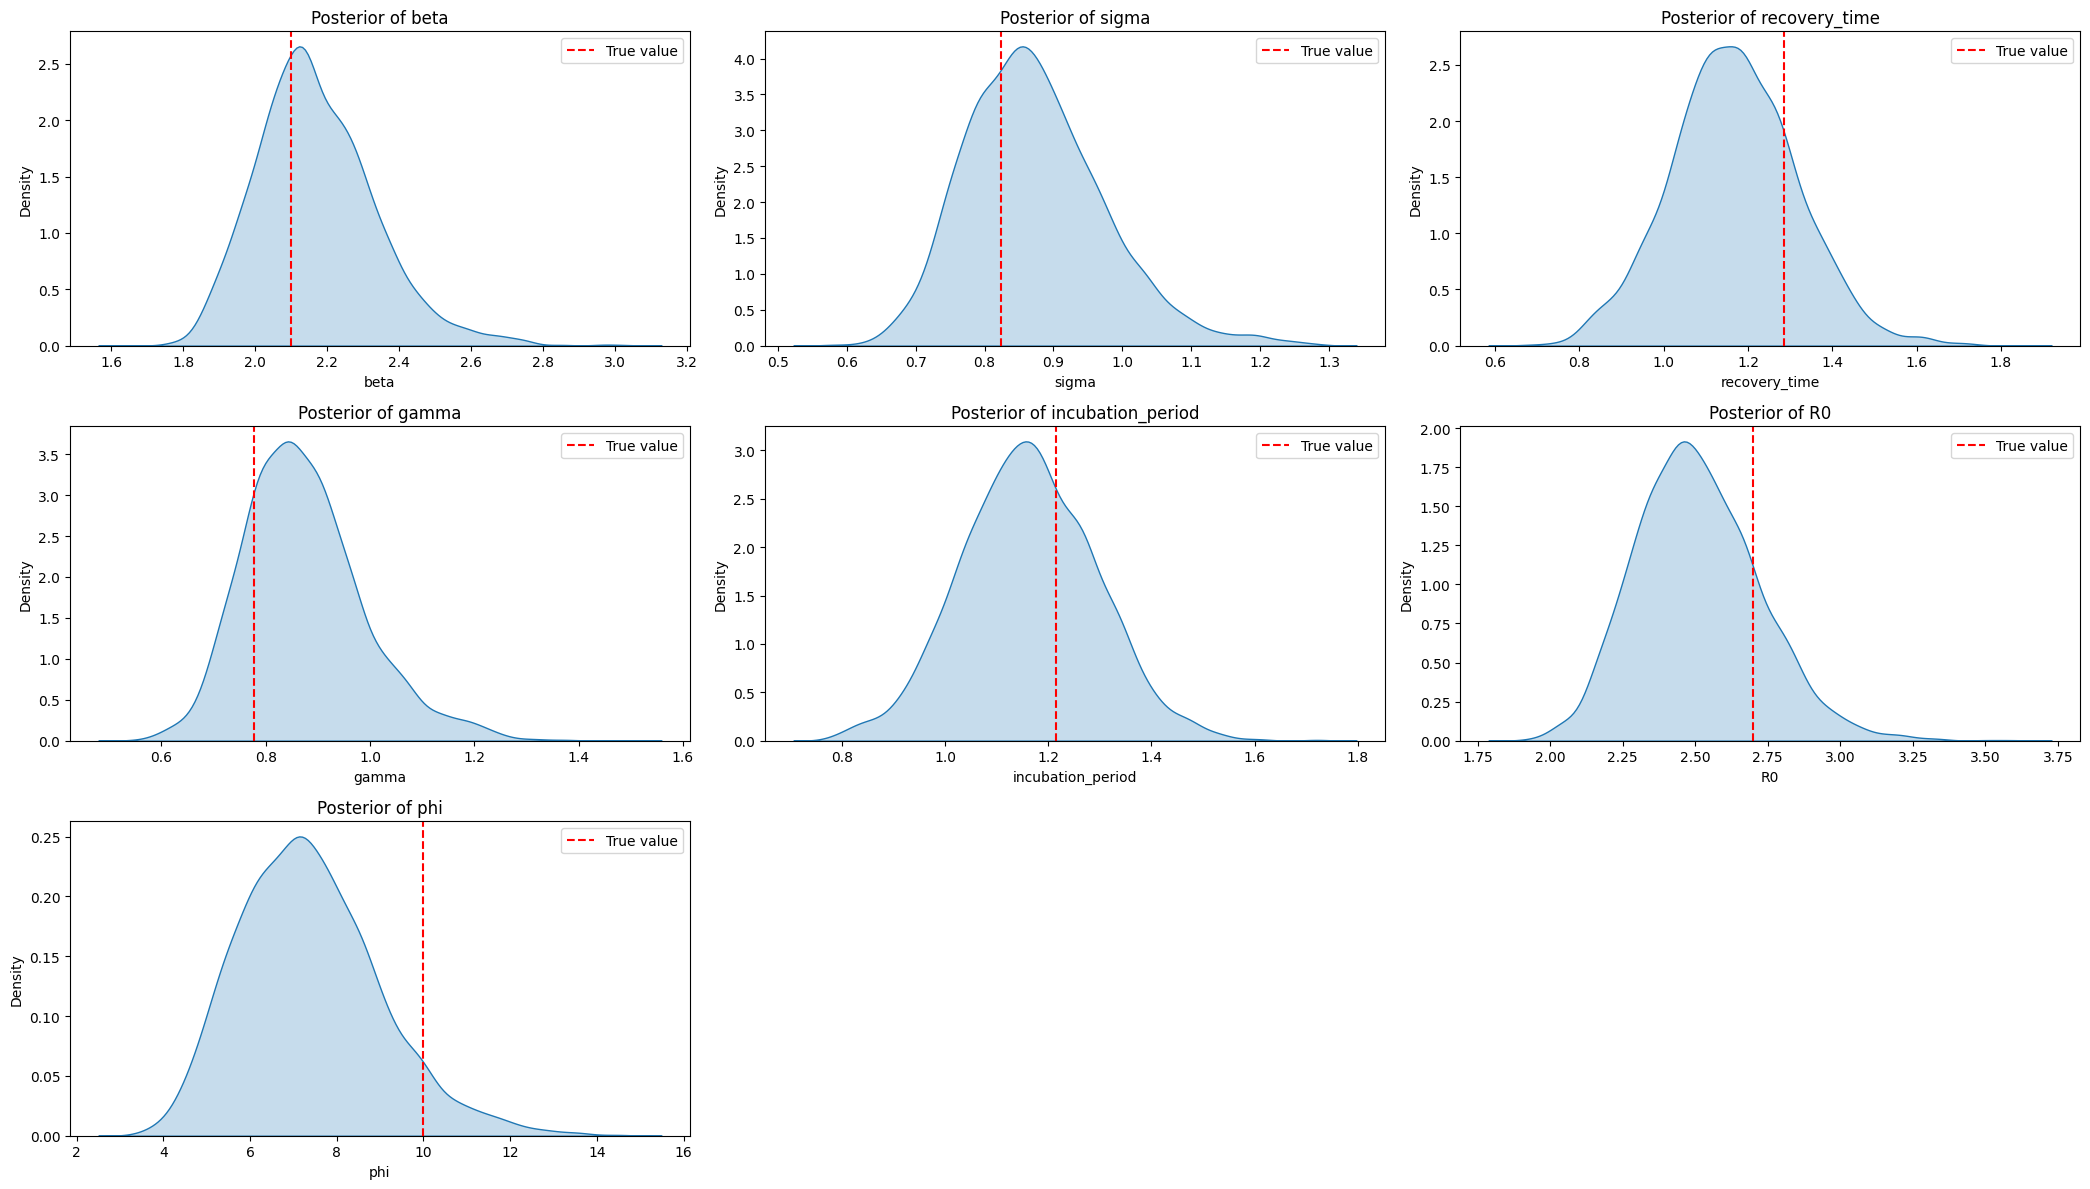

In [37]:
from posterior_plot import plot_posterior_kde_grid

plot_posterior_kde_grid(fit1, parameters1, 3,t1)

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/SEIR/posterior_plot.py:31: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(posterior_samples[param], fill=True, ax=ax[i])
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/SEIR/posterior_plot.py:31: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(posterior_samples[param], fill=True, ax=ax[i])
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/SEIR/posterior_plot.py:31: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(posterior_samples[param], fill=True, ax=ax[i])


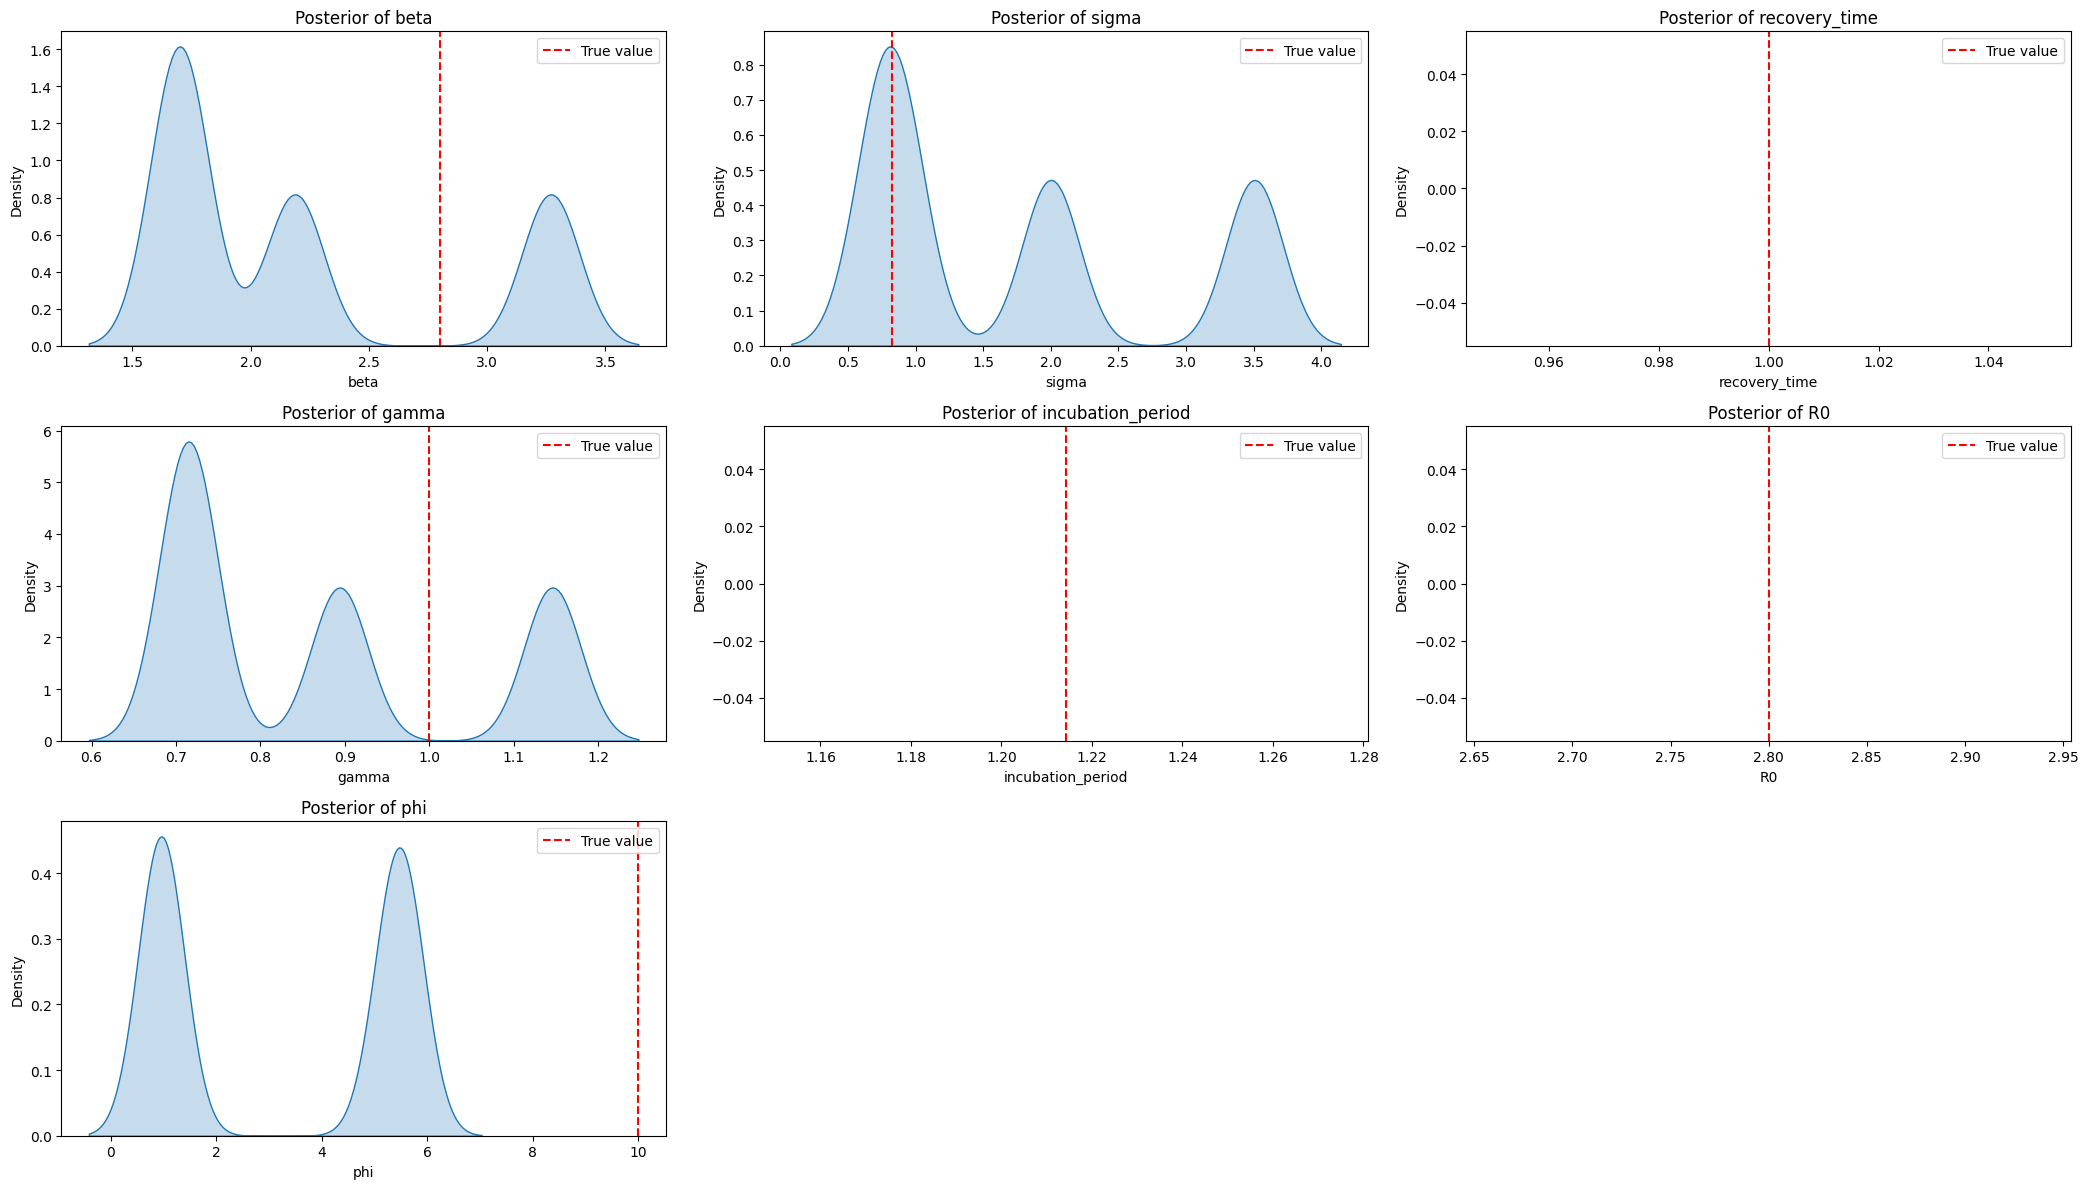

In [38]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2)

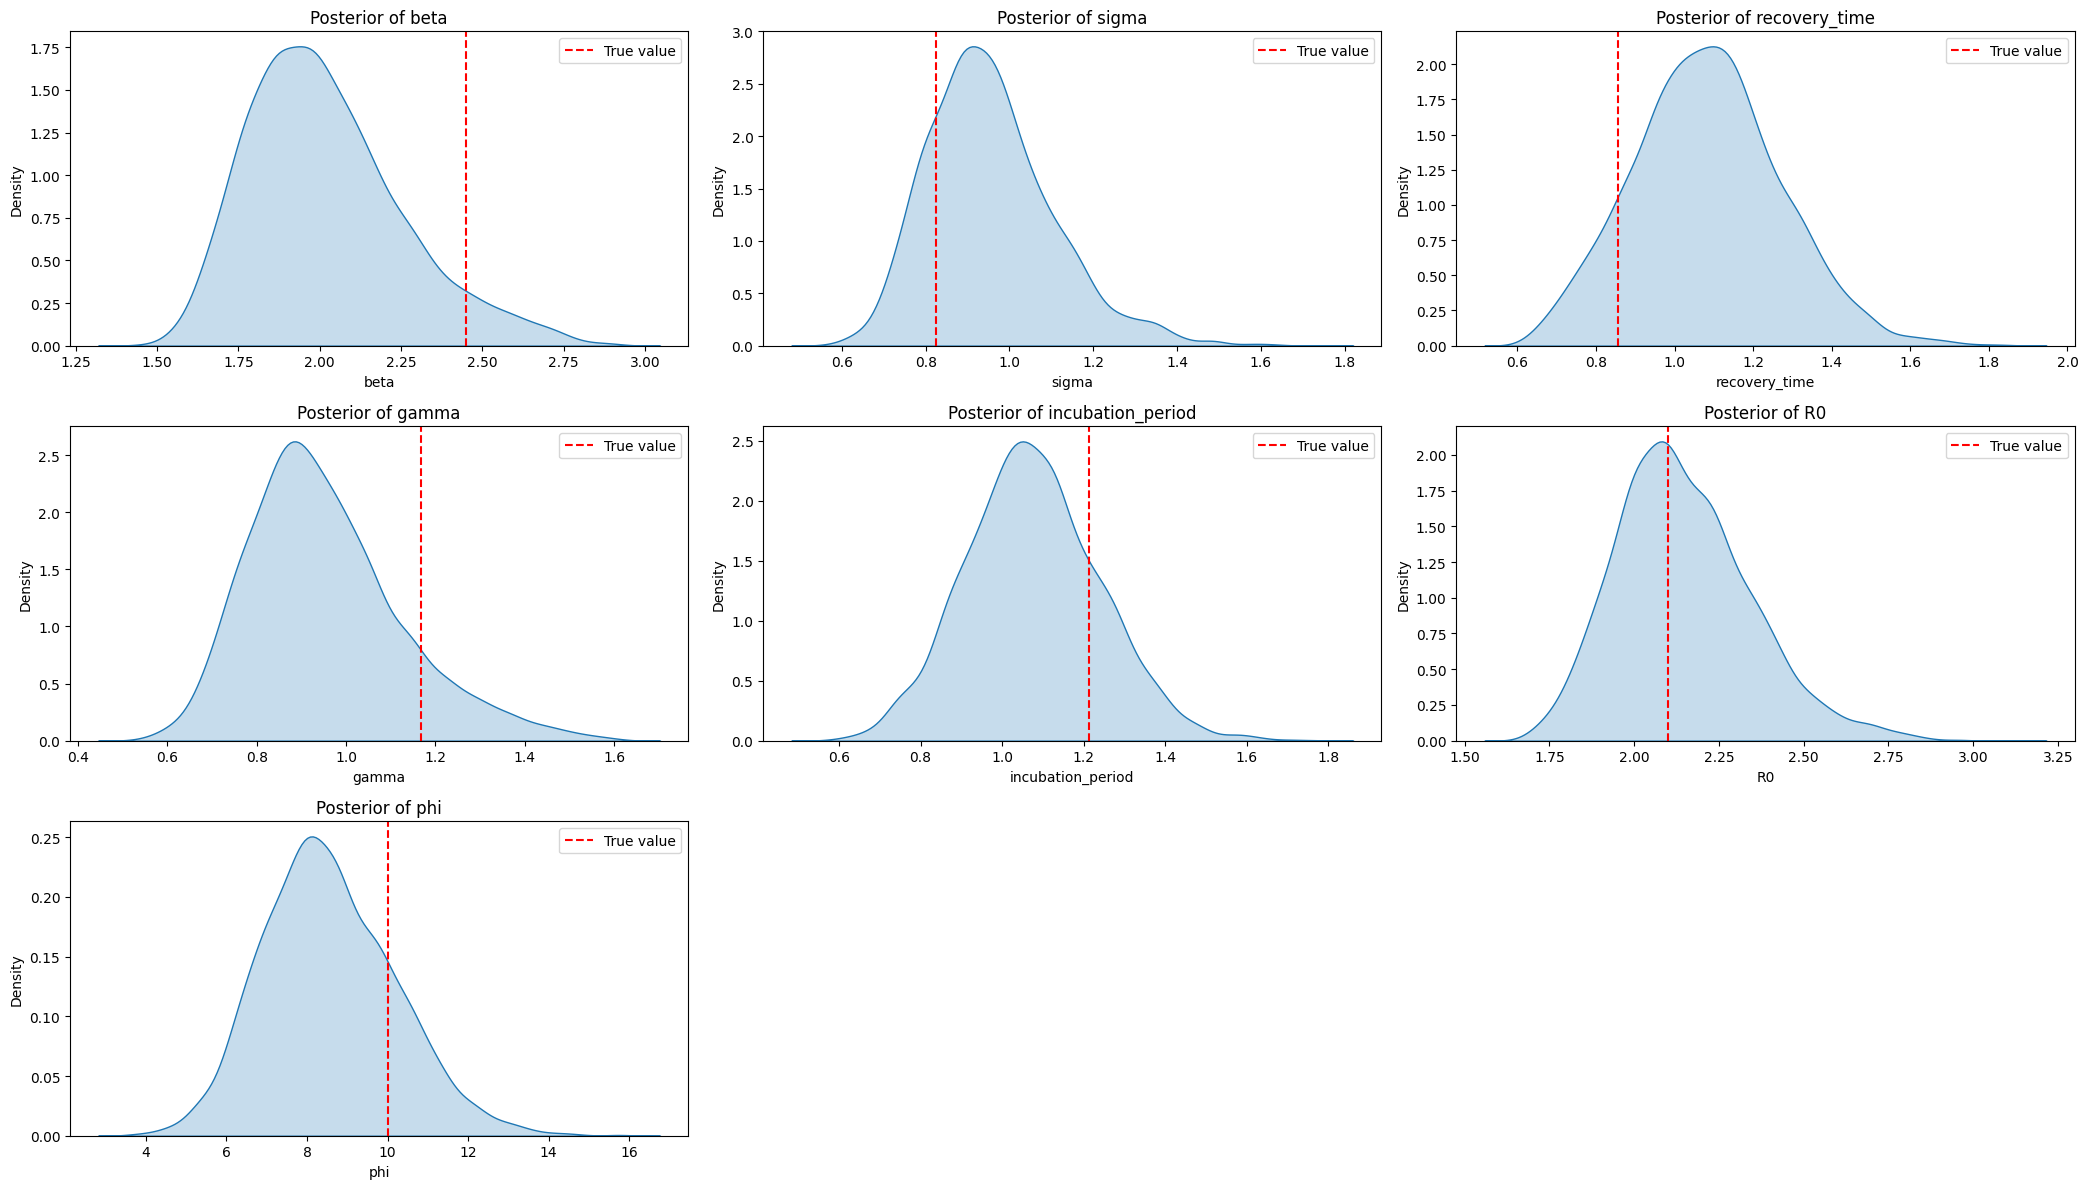

In [39]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3)

## Plot SEIR Compartments

In [46]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 6))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

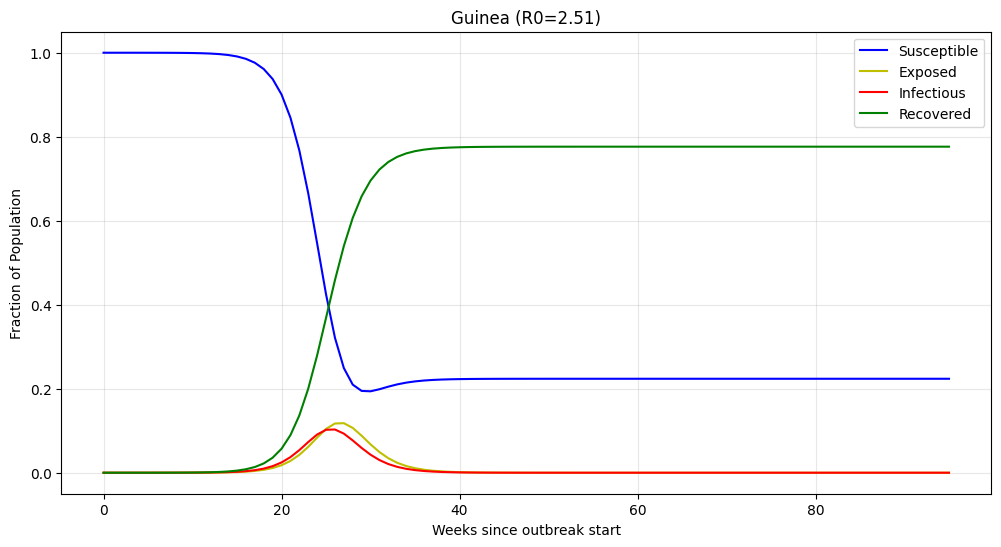

In [47]:
plot_compartment(fit1, country_idx=0)
# plot_compartment(fit2, country_idx=1)
# plot_compartment(fit3, country_idx=2)

# Plot R0

/tmp/ipykernel_9482/725299657.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(R0_fit2, label='Liberia', color='green', fill=True)


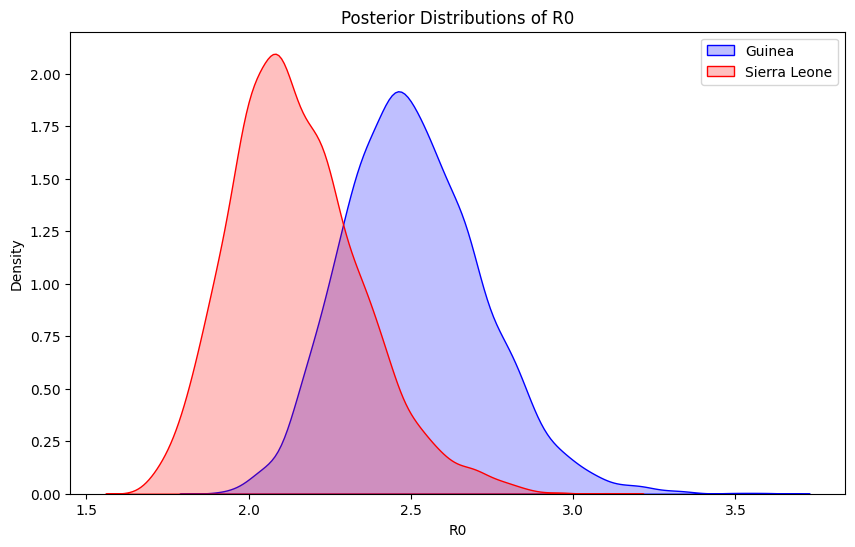

In [48]:
# Extract posterior samples
R0_fit1 = fit1.stan_variable('R0')
R0_fit2 = fit2.stan_variable('R0')
R0_fit3 = fit3.stan_variable('R0')

# Create the plot
plt.figure(figsize=(10, 6))
sns.kdeplot(R0_fit1, label='Guinea', color='blue', fill=True)
sns.kdeplot(R0_fit2, label='Liberia', color='green', fill=True)
sns.kdeplot(R0_fit3, label='Sierra Leone', color='red', fill=True)

# Customize the plot
plt.title('Posterior Distributions of R0')
plt.xlabel('R0')
plt.ylabel('Density')
plt.legend()
plt.grid(False)
plt.show()

/tmp/ipykernel_9482/3482465551.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([R0_fit1, R0_fit2, R0_fit3], labels=['Guinea', 'Liberia', 'Sierra Leone'])


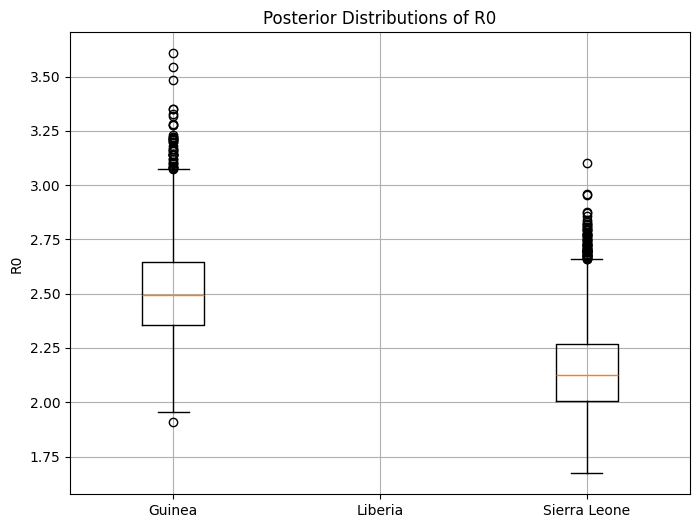

In [49]:
plt.figure(figsize=(8, 6))
plt.boxplot([R0_fit1, R0_fit2, R0_fit3], labels=['Guinea', 'Liberia', 'Sierra Leone'])
plt.title('Posterior Distributions of R0')
plt.ylabel('R0')
plt.grid(True)
plt.show()

# FITTING FOR 3 PATCHES

In [32]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.tail()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
91,0,0,0
92,0,0,0
93,0,0,0
94,0,0,0
95,0,0,0


In [ ]:
%run fit_multi.py

Running model fit for All Patches at time 20250610_183519...

Done compiling...Now Sampling!


In [53]:
# Load Guinea fit
fit_multi_model = from_csv('outputs/all_Patches_20250610_171841/mult-*_*.csv')
print("All fit loaded")
print(fit_multi_model.diagnose())

All fit loaded
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [54]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", 
                               "sigma[1]","sigma[2]","sigma[3]",
                                 "gamma[1]","gamma[2]","gamma[3]", "phi"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],1.970740,0.006633,0.530956,0.484877,1.231350,1.904700,2.93177,7067.91,3331.78,1.000810
beta[2],3.837010,0.012358,0.858038,0.814207,2.603260,3.752250,5.37648,4957.69,3423.93,0.999803
beta[3],3.088310,0.010333,0.737180,0.708527,2.020910,3.010920,4.40234,5749.88,2769.95,1.000570
sigma[1],0.781983,0.002896,0.229922,0.211348,0.476954,0.749720,1.21154,7516.91,2955.85,1.002090
sigma[2],1.022890,0.003983,0.278858,0.242512,0.643874,0.979476,1.54028,5596.94,2984.79,1.000080
sigma[3],0.963568,0.003577,0.266418,0.250406,0.603378,0.928795,1.44193,6508.06,3499.66,1.003090
gamma[1],0.833538,0.003226,0.248789,0.223884,0.494063,0.801381,1.29435,6472.02,3209.06,1.001440
gamma[2],0.914802,0.003326,0.254549,0.238361,0.553498,0.881619,1.37927,6335.40,2984.82,1.000730
gamma[3],1.085610,0.003926,0.298084,0.286516,0.661623,1.055570,1.63086,6411.30,3039.31,1.002260
phi,1.181290,0.009252,0.580660,0.436374,0.541935,1.059620,2.22374,5755.75,2888.04,1.000230


In [55]:

multy_fit_summary.filter(items=("recovery_time[1]", "recovery_time[2]", "recovery_time[3]",
                                "R0[1]","R0[2]", "R0[3]", 
                               "incubation_period[1]","incubation_period[2]","incubation_period[3]"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
recovery_time[1],1.306600,0.005338,0.393162,0.344482,0.772588,1.247840,2.02403,6472.00,3209.06,1.001810
recovery_time[2],1.178680,0.004332,0.331358,0.305657,0.725024,1.134270,1.80669,6335.46,2984.82,1.000370
recovery_time[3],0.992522,0.003736,0.279039,0.255058,0.613174,0.947356,1.51144,6411.30,3039.31,1.002900
R0[1],2.551450,0.013648,0.982631,0.855460,1.296310,2.385910,4.40410,7077.17,3058.55,1.001770
R0[2],4.457350,0.019133,1.418460,1.299510,2.567050,4.241530,7.17519,6227.91,3439.07,1.001850
R0[3],3.023820,0.013657,1.012920,0.903148,1.716610,2.849590,4.87329,6733.89,3199.79,1.000780
incubation_period[1],1.386280,0.004737,0.395443,0.380880,0.825393,1.333840,2.09664,7516.98,2955.85,1.002510
incubation_period[2],1.047420,0.003788,0.276291,0.260672,0.649234,1.020950,1.55310,5596.94,2984.79,0.999774
incubation_period[3],1.114850,0.003754,0.300306,0.287179,0.693518,1.076660,1.65734,6508.05,3499.66,1.003080


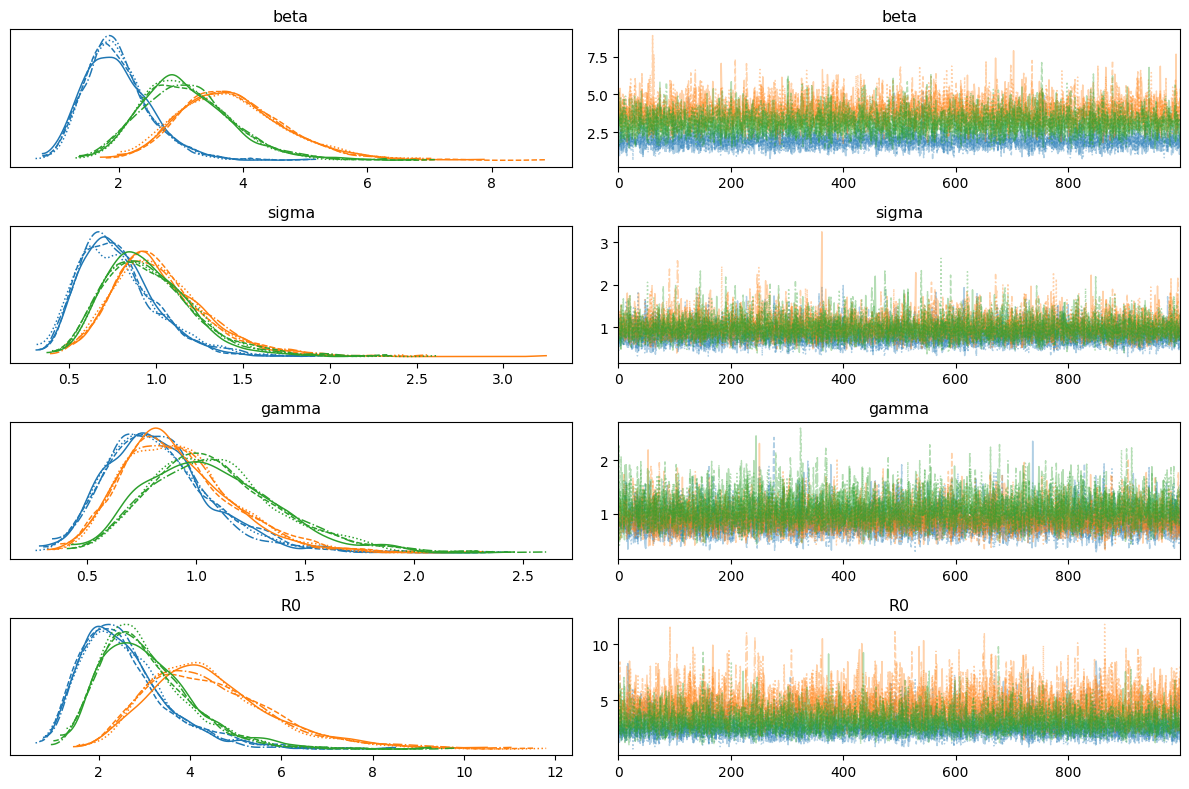

In [56]:
# # Extract posterior samples
# post_no = fit_multi_model.draws_pd()

# ## save the posterior samples
# post_no.to_csv('./Data/posterior_samples_no_coupling.csv', index=False)
az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

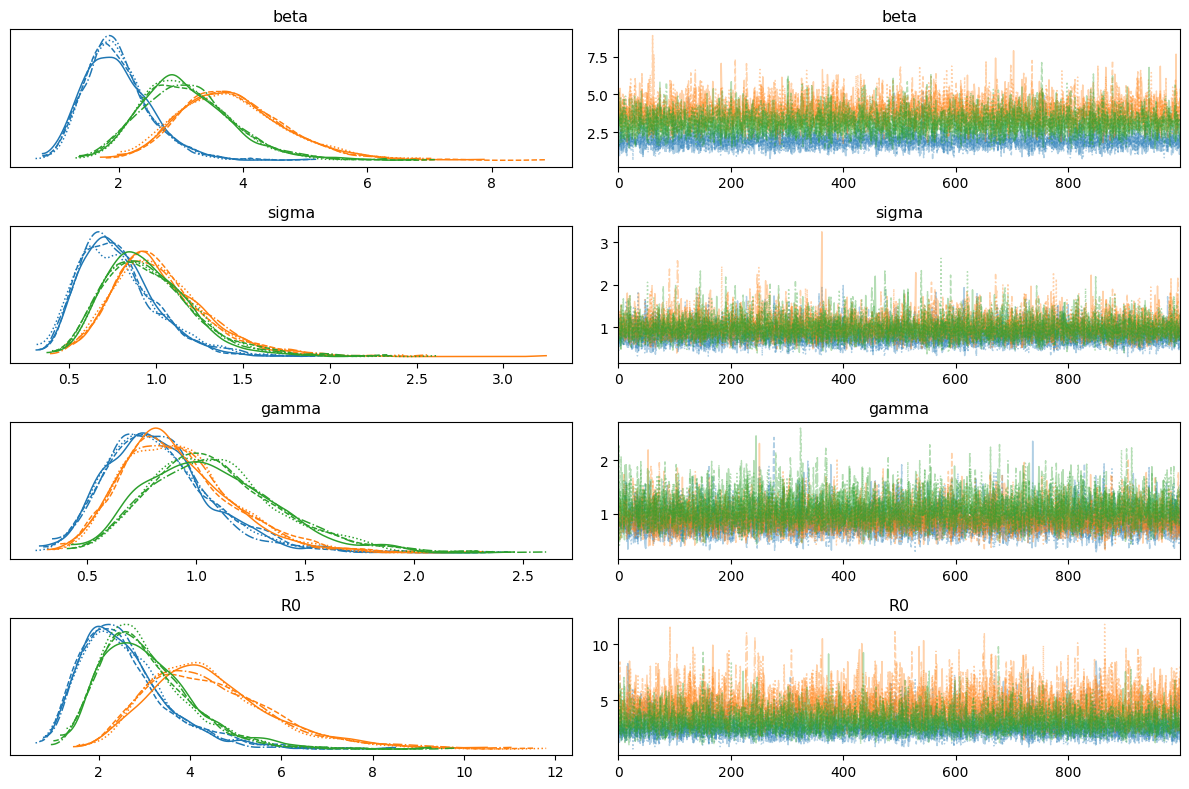

In [57]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [58]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7  # 1/infectious period (Ebola: ~7 days)

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

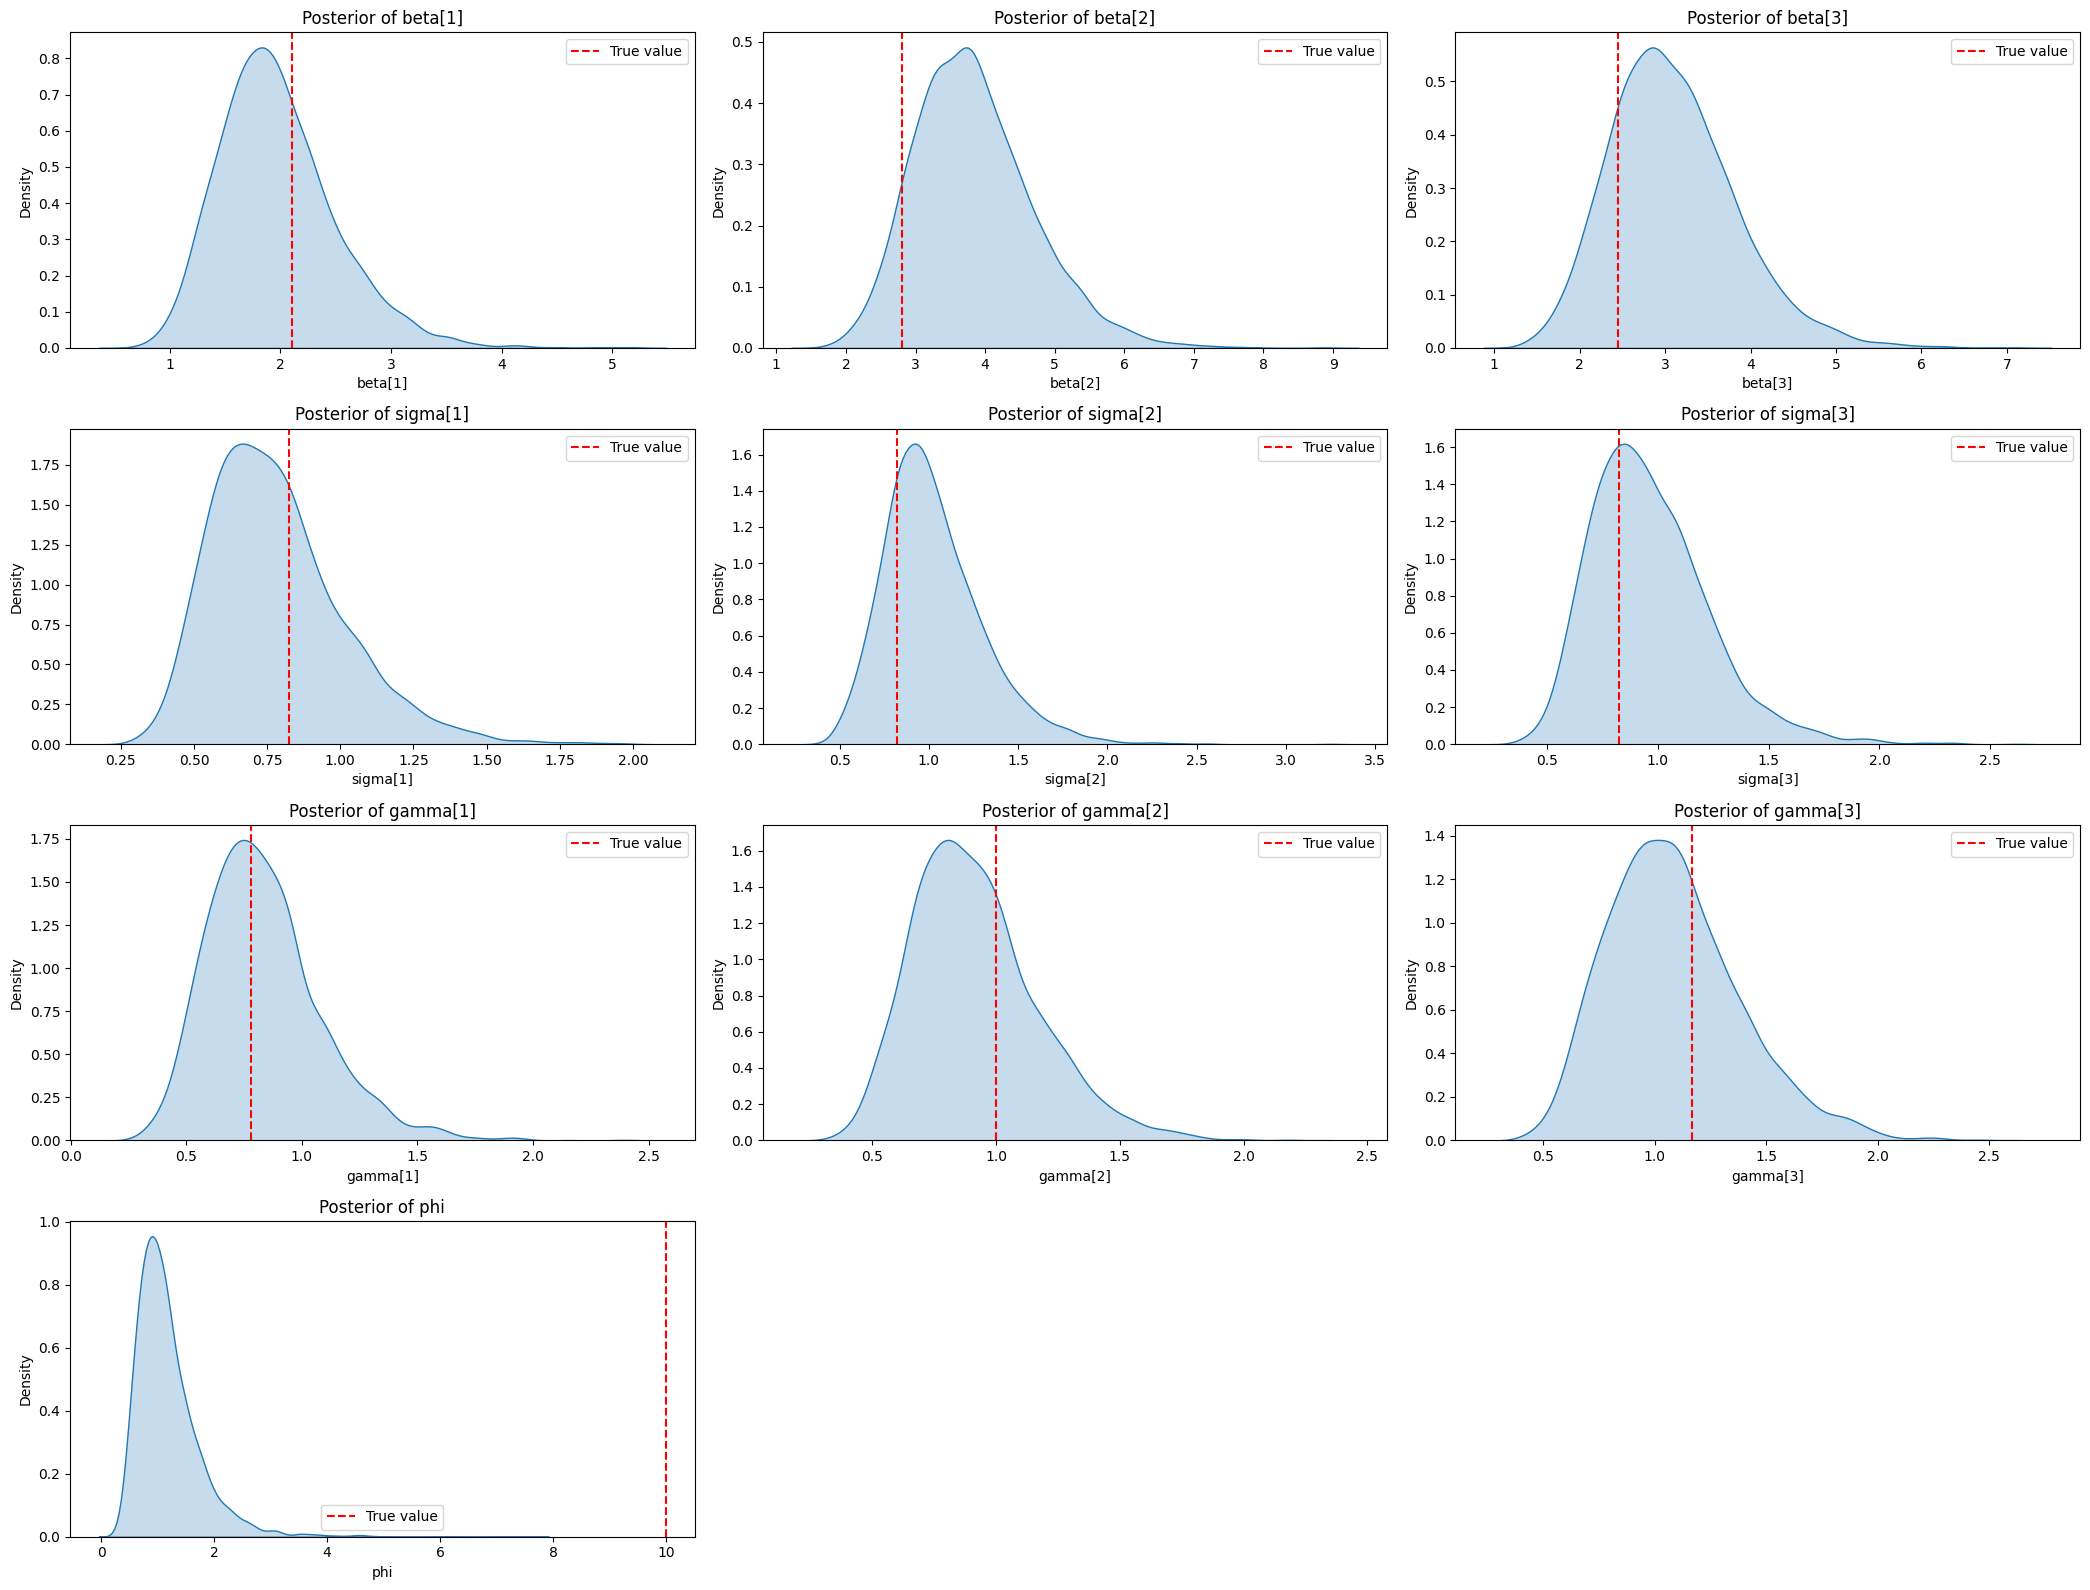

In [63]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
              "sigma[1]","sigma[2]","sigma[3]",
              "gamma[1]","gamma[2]","gamma[3]",'phi']
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma[1]': sigma[0], 'sigma[2]': sigma[1],'sigma[3]': sigma[2], 
    'gamma[1]': gamma[0],'gamma[2]': gamma[1],'gamma[3]': gamma[2],
    'phi': phi , 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t)

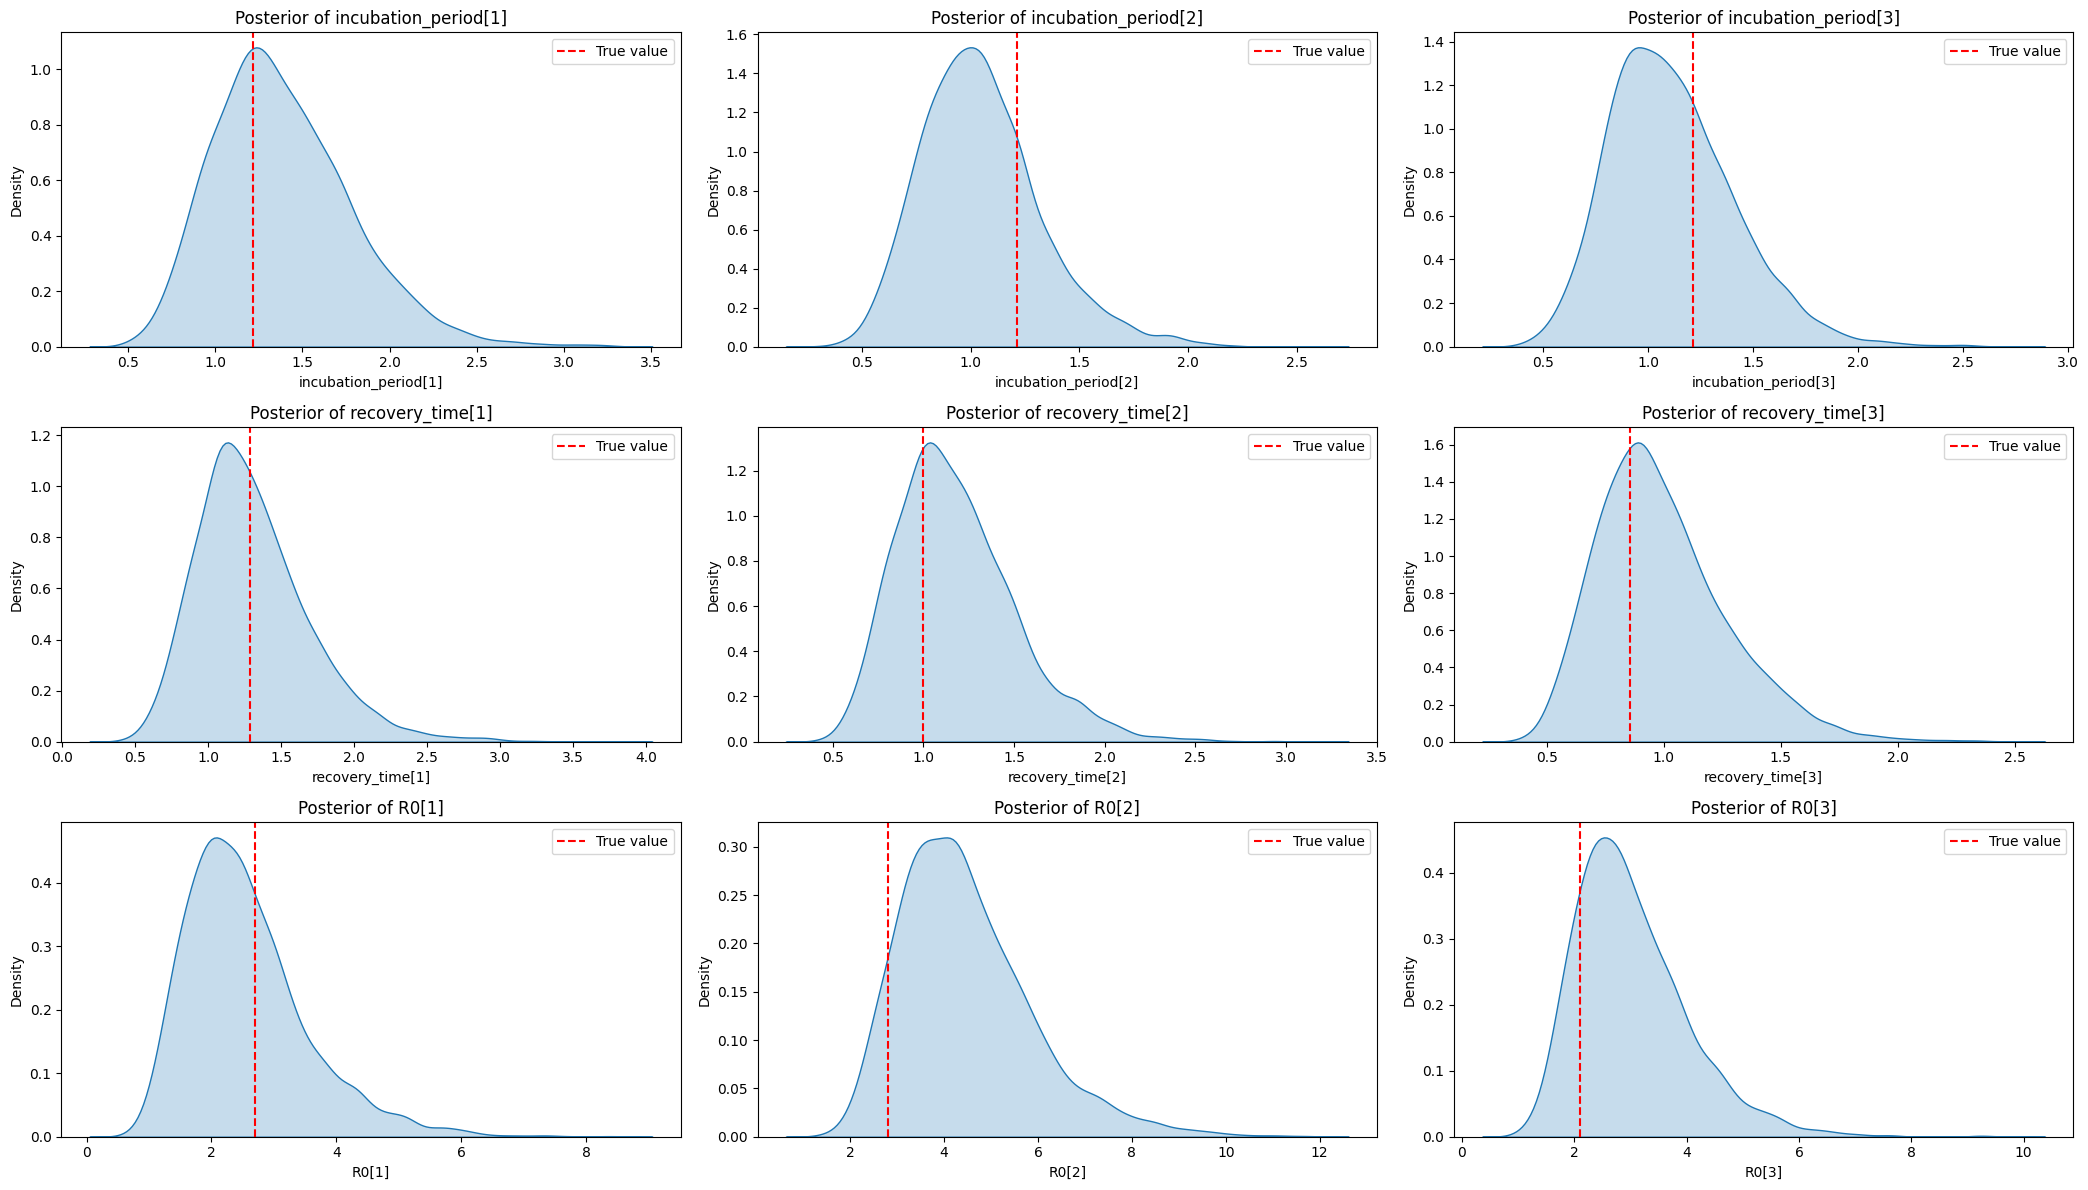

In [61]:
parameters1 = ["incubation_period[1]","incubation_period[2]","incubation_period[3]",
               "recovery_time[1]","recovery_time[2]","recovery_time[3]",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time[1]':rec[0], 'recovery_time[2]':rec[1], 'recovery_time[3]':rec[2],
    'incubation_period[1]': incu[0], 'incubation_period[2]': incu[1], 'incubation_period[3]': incu[2]}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1)

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▉         | 00:18 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:41 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 02:10 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:14 Iteration:  300 / 2000 [ 15%]  (Warmup)




















chain 1 |██▋       | 08:19 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 08:22 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 08:27 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 08:42 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 08:44 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 08:56 Iteration: 1000 / 2000 [ 50%]  (Warmup)

chain 1 |████████▏ | 09:34 Iteration: 1500 / 2000 [ 75%]  (Sampling)

chain 1 |████████▋ | 09:40 Iteration: 1600 / 2000 [ 80%]  (Sampling)

chain 1 |█████████ | 09:55 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |█████████▌| 09:58 Iteration: 1800 / 2000 [ 90%

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


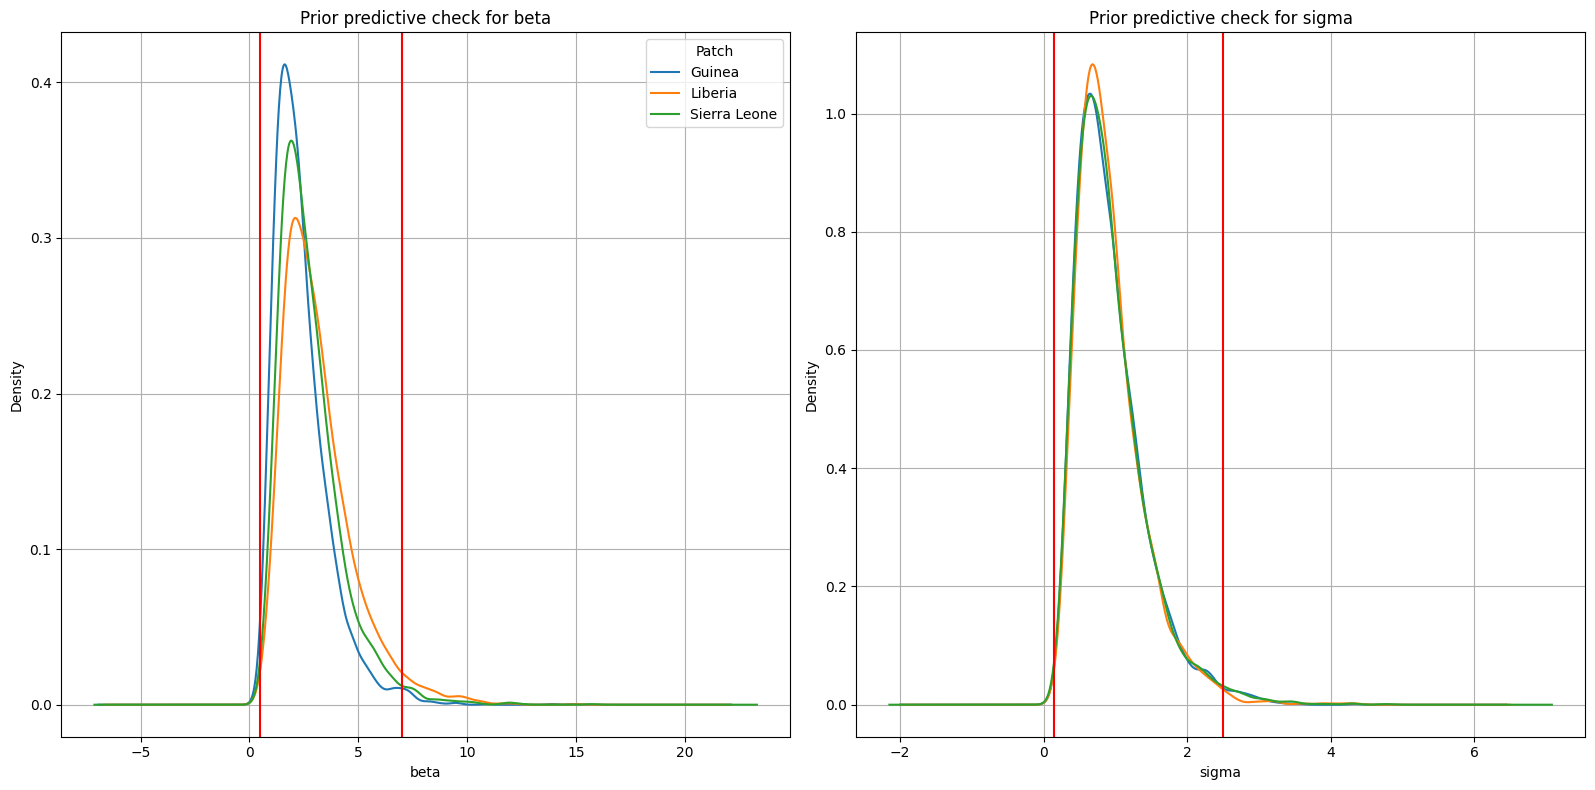

In [ ]:
params = ['beta','sigma', 'gamma']
boundaries = [0.5, 7, 0.14, 2.5, 0.1, 2.0]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()